# Empirical Finance - 20999

# Lab 8: Principal Component Analysis

This lab is organized in two complementary parts.

The first part reviews the key results from the **spectral decomposition theorem**, with particular emphasis on the construction and interpretation of eigenvalues and eigenvectors.  

In the second part, we apply these concepts to the study of the yield curve. Using daily yield changes across maturities, we perform a **PCA-based analysis** to uncover the dominant factors that drive movements in interest rates.


### The spectral decomposition of a variance-covariance matrix

Let $\mathbf{r}$ be a three-dimensional (row) random vector with
$$\text{st.d} \left[ r_{1}\right] =0.2, \quad \text{st.d} \left[ r_{2}\right] =0.25, \quad \text{st.d} \left[ r_{3}\right] =0.3 $$
$$ \text{corr} \left[ r_{1},r_{2}\right] =0.3, \quad\text{corr} \left[ r_{1},r_{3}\right]=-0.5, \quad \text{corr} \left[ r_{2},r_{3}\right] =0.2. $$
The variance-covariance matrix $\boldsymbol{\Sigma}$ of $\mathbf{r}$ reads
\begin{equation*}
\Sigma =\left[
\begin{array}{ccc}
0.04 & 0.015 & -0.03 \\
0.015 & 0.0625 & 0.015 \\
-0.03 & 0.015 & 0.09%
\end{array}%
\right] .
\end{equation*}

In [ ]:
import numpy as np

Sigma = np.array( [ [0.04, 0.015, -0.03], [0.015, 0.0625, 0.015], [-0.03, 0.015, 0.09]] )

As a sanity check, we verify that this matrix is a valid variance-covariance matrix by confirming that it is (at least) positive semi-definite, testing whether its first three leading principal minors are non-negative.

In [ ]:
non_negative_minors = 0

for i in range(Sigma.shape[0]):
  if np.linalg.det(Sigma[:i+1, :i+1]) >= 0:
    non_negative_minors += 1

In [ ]:
non_negative_minors == Sigma.shape[0]

True

We now compute the spectral decomposition of $\boldsymbol{\Sigma}$.

In particular, for a generic symmetric, non-singular matrix $\mathbf{A} \in \mathbb{R}^{m \times m}$, we seek an orthogonal matrix $\mathbf{X}$ and a diagonal matrix $\boldsymbol{\Lambda}$ such that
$$
\mathbf{A} = \mathbf{X} \boldsymbol{\Lambda} \mathbf{X}',
$$
where the diagonal elements of $\boldsymbol{\Lambda}$ are, by convention, ordered from largest to smallest,
$$
\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_m,
$$
and the columns of $\mathbf{X}$ form an orthonormal set, satisfying
$$
\mathbf{x}_i' \mathbf{x}_i = \|\mathbf{x}_i\|^2 = 1 \quad \text{for } i = 1,\dots,m,
$$
$$
\mathbf{x}_i' \mathbf{x}_j = 0 \quad \text{for } i \neq j.
$$
As a consequence, the pairs $\{(\lambda_i, \mathbf{x}_i)\}_{i=1}^m$ are eigenvalue–eigenvector pairs satisfying
$$
\mathbf{A} \mathbf{x}_i = \lambda_i \mathbf{x}_i,
$$
for each $i$.

If we had to solve this problem explicitly, we would first derive and solve the characteristic equation of $\mathbf{A}$, defined as
$$
\det\!\left[ \mathbf{A} - \lambda \mathbf{I}_{m} \right] = 0.
$$
Then, for each of the $m$ resulting eigenvalues $\{\lambda_i\}_{i=1}^m$, we would determine the associated eigenvector by solving $\mathbf{A} \mathbf{x}_i = \lambda_i \mathbf{x}_i$ under the constraint $\mathbf{x}_i' \mathbf{x}_i = 1$.

Consider the matrix $\boldsymbol{\Sigma}$ above. We compute
\begin{equation*}
\det \left[ \left[
\begin{array}{ccc}
0.04 & 0.015 & -0.03 \\
0.015 & 0.0625 & 0.015 \\
-0.03 & 0.015 & 0.09
\end{array}
\right] -\left[
\begin{array}{ccc}
\lambda & 0 & 0 \\
0 & \lambda & 0 \\
0 & 0 & \lambda
\end{array}
\right] \right] =\det \left[
\begin{array}{ccc}
0.04-\lambda & 0.015 & -0.03 \\
0.015 & 0.0625-\lambda & 0.015 \\
-0.03 & 0.015 & 0.09-\lambda
\end{array}
\right] =
\end{equation*}
which expands to
$$
-\lambda^{3} + 0.1925\,\lambda^{2} - 0.010375\,\lambda + 0.000126 \overset{!}{=} 0.
$$
This polynomial has solutions
$$
\lambda_1 = 0.1054, \qquad
\lambda_2 = 0.0700, \qquad
\lambda_3 = 0.0171,
$$
the three eigenvalues of $\boldsymbol{\Sigma}$.

To find the eigenvector associated with the largest eigenvalue $\lambda_1 = 0.1054$, we solve
$$
\begin{bmatrix}
0.04 & 0.015 & -0.03 \\
0.015 & 0.0625 & 0.015 \\
-0.03 & 0.015 & 0.09
\end{bmatrix}
\begin{bmatrix}
x \\ y \\ z
\end{bmatrix}
=
0.1054
\begin{bmatrix}
x \\ y \\ z
\end{bmatrix}.
$$
This system is equivalent to
$$
\left\{
\begin{aligned}
0.04x + 0.015y - 0.03z &= 0.1054\,x, \\[2pt]
0.015x + 0.0625y + 0.015z &= 0.1054\,y, \\[2pt]
-0.03x + 0.015y + 0.09z &= 0.1054\,z,
\end{aligned}
\right.
$$
and is solved by
$$
\begin{bmatrix}
x \\ y \\ z
\end{bmatrix}
=
\begin{bmatrix}
-0.41152\, z \\[2pt]
\phantom{-}0.20576\, z \\[2pt]
z
\end{bmatrix}.
$$

Imposing the unit-norm constraint,
$$
(-0.41152z)^2 + (0.20576z)^2 + z^2 \overset{!}{=} 1,
$$
we obtain
$$
z = \pm\,0.90846.
$$
Choosing the positive value yields the normalized eigenvector
$$
\mathbf{x}_1 =
\begin{bmatrix}
-0.41152\,z \\[2pt]
\phantom{-}0.20576\,z \\[2pt]
z
\end{bmatrix}
=
\begin{bmatrix}
-0.37373 \\[2pt]
\phantom{-}0.18687 \\[2pt]
0.90846
\end{bmatrix}.
$$

Finally, note that eigenvectors are defined only up to sign: flipping the sign of any column of $\mathbf{X}$ does not affect the spectral decomposition, since $\mathbf{X}$ appears twice.


In order to compute such a decomposition for our matrix $\boldsymbol{\Sigma}$, we rely on the `eigh` function (where `eig` refers to eigenvalues and eigenvectors, and the final `h` denotes Hermitian matrices, which, in the case of real-valued square matrices, correspond to symmetric matrices) from the `numpy.linalg` package.

In [ ]:
vals, vecs = np.linalg.eigh(Sigma)

In [ ]:
vals

array([0.01707351, 0.07      , 0.10542649])

As we can see, the eigenvalues are returned as a one-dimensional NumPy array rather than as a diagonal matrix, and they are ordered from smallest to largest. To adhere to our convention, we reverse the order of this vector and, accordingly, reorder the columns of the orthogonal matrix.

In [ ]:
vals = np.flip(vals)
vals

array([0.10542649, 0.07      , 0.01707351])

In [ ]:
Lambda = np.diag(vals)
Lambda

array([[0.10542649, 0.        , 0.        ],
       [0.        , 0.07      , 0.        ],
       [0.        , 0.        , 0.01707351]])

In [ ]:
vecs

array([[ 8.12600421e-01,  4.47213595e-01, -3.73738620e-01],
       [-4.06300210e-01,  8.94427191e-01,  1.86869310e-01],
       [ 4.17852480e-01, -1.11022302e-16,  9.08514890e-01]])

In [ ]:
X = np.flip(vecs, axis = 1)
X

array([[-3.73738620e-01,  4.47213595e-01,  8.12600421e-01],
       [ 1.86869310e-01,  8.94427191e-01, -4.06300210e-01],
       [ 9.08514890e-01, -1.11022302e-16,  4.17852480e-01]])

Now we can run a few numerical tests to verify that the (modified) output of the `eigh` function indeed corresponds to the elements of the spectral decomposition of $\boldsymbol{\Sigma}$.

In [ ]:
X @ Lambda @ X.T

array([[ 0.04  ,  0.015 , -0.03  ],
       [ 0.015 ,  0.0625,  0.015 ],
       [-0.03  ,  0.015 ,  0.09  ]])

In [ ]:
Sigma

array([[ 0.04  ,  0.015 , -0.03  ],
       [ 0.015 ,  0.0625,  0.015 ],
       [-0.03  ,  0.015 ,  0.09  ]])

In [ ]:
X @ X.T

array([[ 1.00000000e+00, -4.44089210e-16,  1.66533454e-16],
       [-4.44089210e-16,  1.00000000e+00,  3.05311332e-16],
       [ 1.66533454e-16,  3.05311332e-16,  1.00000000e+00]])

In [ ]:
x1 = X[:, 0]
lambda1 = Lambda[0,0]
x2 = X[:, 1]
lambda2 = Lambda[1,1]
x3 = X[:, 2]
lambda3 = Lambda[2,2]

In [ ]:
x1.T @ x1

np.float64(0.9999999999999998)

In [ ]:
x1 @ x1

np.float64(0.9999999999999998)

In [ ]:
x1 @ x1.T

np.float64(0.9999999999999998)

In [ ]:
x1 @ x2

np.float64(2.5995706810865226e-16)

In [ ]:
x1 @ x3

np.float64(-1.1102230246251565e-16)

In [ ]:
Sigma @ x1 == lambda1 * x1

array([False, False, False])

In [ ]:
Sigma @ x1 - lambda1 * x1

array([-6.93889390e-18, -1.73472348e-17,  1.38777878e-17])

We can also verify whether the two well-known relationships involving the sum and the product of the eigenvalues hold. In particular, we check that
$$ \text{det} \left[ \boldsymbol{\Sigma} \right] = \prod_{i=1}^m \lambda_i $$
and
$$ \text{tr} \left[ \boldsymbol{\Sigma} \right] = \sum_{i=1}^m \lambda_i,$$
where the trace of a square matrix $\mathbf{A} \in \mathbb{R}^{m \times m}$ is defined as the sum of the elements along its main diagonal, $\text{tr} \left[ \mathbf{A} \right] = \sum_{i=1}^m A_{i,i}$.

In [ ]:
np.linalg.det(Sigma)

np.float64(0.00012599999999999995)

In [ ]:
vals.prod()

np.float64(0.00012599999999999995)

In [ ]:
np.linalg.trace(Sigma)

np.float64(0.1925)

In [ ]:
Sigma[0,0] + Sigma[1,1] + Sigma[2,2]

np.float64(0.1925)

In [ ]:
vals.sum()

np.float64(0.1925)

Importantly, we also verify that
$$
\boldsymbol{\Sigma} = \sum_{i=1}^{m} \lambda_{i}\, \mathbf{x}_{i}\mathbf{x}_{i}',
$$
that is, the original matrix $\boldsymbol{\Sigma}$ can be expressed as the sum of $m$ symmetric matrices, each of rank one. Indeed, for any $i$, the matrix $\mathbf{x}_{i}\mathbf{x}_{i}' \in \mathbb{R}^{m \times m}$ is the outer product of a vector with itself, and it is symmetric with rank equal to one.

In our example, where $m = 3$, we therefore need to verify that
$$
\boldsymbol{\Sigma}
= \lambda_{1}\, \mathbf{x}_{1}\mathbf{x}_{1}'
+ \lambda_{2}\, \mathbf{x}_{2}\mathbf{x}_{2}'
+ \lambda_{3}\, \mathbf{x}_{3}\mathbf{x}_{3}'.
$$

In [ ]:
x1 @ x1.T

np.float64(0.9999999999999998)

In [ ]:
np.outer(x1, x1)

array([[ 0.13968056, -0.06984028, -0.3395471 ],
       [-0.06984028,  0.03492014,  0.16977355],
       [-0.3395471 ,  0.16977355,  0.82539931]])

In [ ]:
np.linalg.matrix_rank( np.outer(x1, x1) )

np.int64(1)

In [ ]:
lambda1 * np.outer(x1, x1) +lambda2 * np.outer(x2, x2) + lambda3 * np.outer(x3, x3)

array([[ 0.04  ,  0.015 , -0.03  ],
       [ 0.015 ,  0.0625,  0.015 ],
       [-0.03  ,  0.015 ,  0.09  ]])

In [ ]:
Sigma

array([[ 0.04  ,  0.015 , -0.03  ],
       [ 0.015 ,  0.0625,  0.015 ],
       [-0.03  ,  0.015 ,  0.09  ]])

Regarding the interpretation of the principal components, it is important to note that the eigenvalue-eigenvector pairs of any variance-covariance matrix can be obtained by solving, recursively, a sequence of optimization problems related to maximizing the variance of a linear combination of the underlying variables, subject to the constraint that the sum of squared coefficients equals one.

Focusing again on the matrix $\boldsymbol{\Sigma}$ considered above, the first principal component is obtained as
$$
\begin{array}{ccc}
\mathbf{x}_{1} = & \arg \max & \mathrm{V}\!\left[\,\mathbf{r}\mathbf{x}\,\right] \\
& \mathbf{x} \in \mathbb{R}^{m} & \text{s.t. } \|\mathbf{x}\|^{2} = 1,
\end{array}
$$
which is equivalent to solving
$$
\begin{array}{ccc}
\mathbf{x}_{1} = & \arg \max & \mathbf{x}' \boldsymbol{\Sigma} \mathbf{x} \\
& \mathbf{x} \in \mathbb{R}^{m} & \text{s.t. } \mathbf{x}' \mathbf{x} = 1.
\end{array}
$$

Once $\mathbf{x}_{1}$ is determined, the associated eigenvalue is given by
$$
\lambda_{1} = \mathbf{x}_{1}' \boldsymbol{\Sigma} \mathbf{x}_{1}.
$$

In [ ]:
from scipy.optimize import minimize

def objFct(x, Sigma):
  return - x @ Sigma @ x

m = Sigma.shape[0]

x0 = np.ones(m)/np.sqrt(m)

res = minimize(objFct, x0, Sigma, constraints= ({ 'type':'eq', 'fun': lambda x : x @ x -1 }) )

In [ ]:
type(res)

scipy.optimize._optimize.OptimizeResult

In [ ]:
res.x

array([-0.37374264,  0.18686809,  0.90851349])

In [ ]:
x1

array([-0.37373862,  0.18686931,  0.90851489])

In [ ]:
-res.fun

np.float64(0.10542649323398678)

In [ ]:
lambda1

np.float64(0.10542649261768072)

The next eigenvalue–eigenvector pair can be obtained by solving the same optimization problem after replacing $\boldsymbol{\Sigma}$ with
$$
\tilde{\boldsymbol{\Sigma}} = \boldsymbol{\Sigma} - \lambda_{1}\,\mathbf{x}_{1}\mathbf{x}_{1}',
$$
since $\tilde{\boldsymbol{\Sigma}}$ retains all the eigenvalues and eigenvectors of $\boldsymbol{\Sigma}$ except for $\lambda_{1}$, which is replaced by a zero eigenvalue. In particular, $\tilde{\boldsymbol{\Sigma}}$ now has rank equal to $m-1$.

In [ ]:
Sigma_tilde = Sigma -lambda1*np.outer(x1, x1)
Sigma_tilde

array([[ 0.02527397,  0.02236302,  0.00579726],
       [ 0.02236302,  0.05881849, -0.00289863],
       [ 0.00579726, -0.00289863,  0.00298105]])

In [ ]:
vals_tilde, vecs_tilde = np.linalg.eigh(Sigma_tilde)

In [ ]:
vals

array([0.10542649, 0.07      , 0.01707351])

In [ ]:
np.flip(vals_tilde)

array([7.00000000e-02, 1.70735074e-02, 3.18253009e-17])

In [ ]:
np.flip(vecs_tilde, axis = 1)

array([[-4.47213595e-01, -8.12600421e-01, -3.73738620e-01],
       [-8.94427191e-01,  4.06300210e-01,  1.86869310e-01],
       [ 6.93889390e-16, -4.17852480e-01,  9.08514890e-01]])

In [ ]:
X

array([[-3.73738620e-01,  4.47213595e-01,  8.12600421e-01],
       [ 1.86869310e-01,  8.94427191e-01, -4.06300210e-01],
       [ 9.08514890e-01, -1.11022302e-16,  4.17852480e-01]])

Recalling that
$$
\boldsymbol{\Sigma} = \sum_{i=1}^{m} \lambda_{i}\, \mathbf{x}_{i}\mathbf{x}_{i}',
$$
the remaining eigenvalue-eigenvector pairs can be obtained recursively by solving
$$
\begin{array}{ccc}
\mathbf{x}_{i} = & \arg \max & \mathbf{x}'\!\left( \boldsymbol{\Sigma}
    - \sum_{j=1}^{i-1} \lambda_{j}\,\mathbf{x}_{j}\mathbf{x}_{j}' \right)\! \mathbf{x} \\[6pt]
& \mathbf{x} \in \mathbb{R}^{m} & \text{s.t. } \mathbf{x}'\mathbf{x} = 1,
\end{array}
$$
and then setting
$$
\lambda_{i}
= \mathbf{x}_{i}'\!\left( \boldsymbol{\Sigma}
    - \sum_{j=1}^{i-1} \lambda_{j}\,\mathbf{x}_{j}\mathbf{x}_{j}' \right)\! \mathbf{x}_{i}.
$$

In [ ]:
def objFct(x, Sigma):
    return - x @ Sigma @ x

m = Sigma.shape[0]
x0 = 1/np.sqrt(m)*np.ones(m)

vals_implicit = np.zeros(m)
vecs_implicit = np.zeros( (m,m) )

currentSigma = Sigma

for i in range(Sigma.shape[0]):

  res = minimize(objFct, x0, currentSigma, constraints = ({'type': 'eq', 'fun': lambda x: x @ x -1}))

  vecs_implicit[:,i] = res.x
  vals_implicit[i] = -res.fun

  currentSigma = currentSigma - vals_implicit[i]*np.outer(vecs_implicit[:,i], vecs_implicit[:,i])

In [ ]:
vals_implicit

array([0.10542649, 0.07000003, 0.01707351])

In [ ]:
vals

array([0.10542649, 0.07      , 0.01707351])

In [ ]:
vecs_implicit

array([[-3.73742643e-01,  4.47182119e-01,  8.12673804e-01],
       [ 1.86868094e-01,  8.94443140e-01, -4.06163008e-01],
       [ 9.08513488e-01,  7.37861100e-06,  4.17843425e-01]])

In [ ]:
X

array([[-3.73738620e-01,  4.47213595e-01,  8.12600421e-01],
       [ 1.86869310e-01,  8.94427191e-01, -4.06300210e-01],
       [ 9.08514890e-01, -1.11022302e-16,  4.17852480e-01]])

### The principal components of the yield curve

The dataset contains daily observations from the beginning of 2020 to the end of 2023 for fifteen maturities of the Euro-area yield curve.
These yields are obtained from swap-rate data published by the Intercontinental Exchange (ICE) Group, which provides a standardized and liquid measure of market expectations.

Specifically, for each trading day the dataset reports the yield corresponding to each of the selected maturities, thereby offering a detailed cross-sectional and temporal representation of the euro yield curve.


In [ ]:
import pandas as pd

df = pd.read_excel('Lab8_data.xlsx', index_col=0)

In [ ]:
df

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
2020-01-02,-0.380,-0.290,-0.244,-0.182,-0.118,-0.055,0.010,0.075,0.142,0.204,0.320,0.463,0.595,0.633,0.629
2020-01-03,-0.390,-0.310,-0.277,-0.233,-0.183,-0.128,-0.069,-0.007,0.056,0.115,0.226,0.364,0.491,0.527,0.520
2020-01-06,-0.390,-0.310,-0.279,-0.235,-0.184,-0.128,-0.069,-0.006,0.056,0.117,0.230,0.370,0.502,0.540,0.533
2020-01-07,-0.390,-0.310,-0.281,-0.239,-0.189,-0.134,-0.074,-0.010,0.053,0.114,0.228,0.368,0.499,0.538,0.531
2020-01-08,-0.400,-0.320,-0.291,-0.247,-0.195,-0.140,-0.079,-0.015,0.049,0.110,0.226,0.369,0.504,0.544,0.540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,3.404,2.855,2.592,2.478,2.432,2.417,2.414,2.420,2.430,2.448,2.480,2.506,2.451,2.356,2.268
2023-12-26,3.404,2.855,2.592,2.478,2.432,2.417,2.414,2.420,2.430,2.448,2.480,2.506,2.451,2.356,2.268
2023-12-27,3.368,2.815,2.551,2.435,2.385,2.370,2.371,2.381,2.395,2.413,2.450,2.477,2.426,2.333,2.247
2023-12-28,3.333,2.793,2.529,2.421,2.380,2.367,2.371,2.383,2.397,2.416,2.453,2.480,2.429,2.337,2.252


In [ ]:
maturities = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30])

In [ ]:
len(maturities)

15

Plotting any row of this panel, that is, the vector of yields observed across all maturities on a given day, provides a cross-sectional snapshot of the term structure. Such a plot reveals the shape of the yield curve at that specific date and it is useful for visualizing market expectations about future interest rates.

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact


def plot_curve(i = 0):
    plt.figure(figsize=(10,5))

    plt.plot(maturities, df.iloc[i, :], marker="o")
    plt.xlabel("years")
    plt.ylabel("yield")
    plt.title(f"Euro yield curve on {df.index[i].date()}")
    plt.ylim(-0.6, 4.2)
    plt.axhline(0, color="black", linewidth=1)

    plt.grid(True)
    plt.show()

interact(plot_curve, i=(0, len(df), 1));

interactive(children=(IntSlider(value=0, description='i', max=1041), Output()), _dom_classes=('widget-interact…

Plotting any column of the panel, that is, the time series of yields for a fixed maturity, illustrates the temporal evolution of interest rates at that horizon. Such a plot highlights periods of volatility, persistent trends, and structural breaks, and allows one to assess how monetary policy decisions, macroeconomic conditions, or market events affected that segment of the curve.

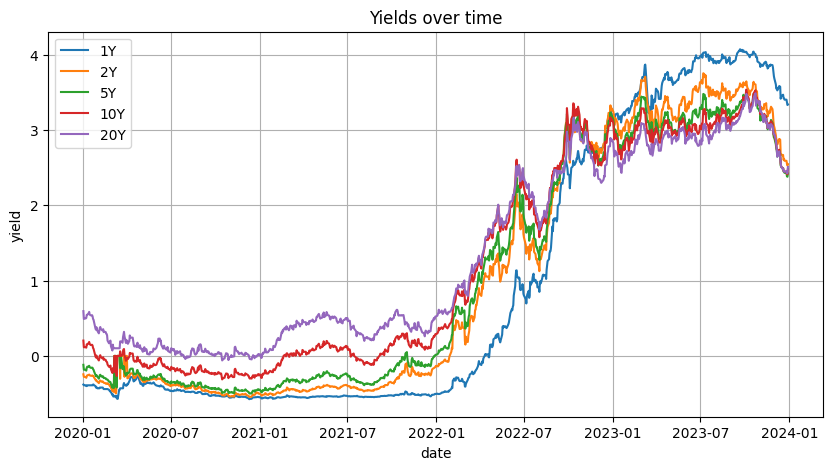

In [ ]:
dates = df.index

plt.figure(figsize=(10,5))

plt.plot(dates, df.iloc[:, 0], label= '1Y')
plt.plot(dates, df.iloc[:, 2], label= '2Y')
plt.plot(dates, df.iloc[:, 4], label= '5Y')
plt.plot(dates, df.iloc[:, 9], label= '10Y')
plt.plot(dates, df.iloc[:, 12], label= '20Y')

plt.xlabel("date")
plt.ylabel("yield")
plt.title("Yields over time")
plt.grid(True)
plt.legend()

plt.show()


Let $\mathbf{Y}$ denote our data panel, where $\mathbf{Y}_{i,j}$ is the yield observed on day $i$ for maturity $j$.

Our main object of interest, however, is not the yield levels themselves but their daily changes. We therefore define the panel of yield variations $\Delta \mathbf{Y}$ row by row as
$$
    \Delta \mathbf{Y}_{t,:} = \mathbf{Y}_{t,:} - \mathbf{Y}_{t-1,:},
$$
that is, the vector of yield movements across all maturities from day $t-1$ to day $t$.

Note: From a statistical and econometric perspective, yield changes exhibit more stable properties, are typically closer to stationarity, and form the basis of most explicit probabilistic models of interest-rate dynamics. In analogy with how asset prices are transformed into returns, it is customary to work with changes in yields rather than their levels: unlike prices, yields are not multiplicative objects, so simple differences are therefore the natural transformation.




In [ ]:
dY = df -df.shift(1)
dY = dY.dropna()
dY

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
2020-01-03,-0.010,-0.020,-0.033,-0.051,-0.065,-0.073,-0.079,-0.082,-0.086,-0.089,-0.094,-0.099,-0.104,-0.106,-0.109
2020-01-06,0.000,0.000,-0.002,-0.002,-0.001,0.000,0.000,0.001,0.000,0.002,0.004,0.006,0.011,0.013,0.013
2020-01-07,0.000,0.000,-0.002,-0.004,-0.005,-0.006,-0.005,-0.004,-0.003,-0.003,-0.002,-0.002,-0.003,-0.002,-0.002
2020-01-08,-0.010,-0.010,-0.010,-0.008,-0.006,-0.006,-0.005,-0.005,-0.004,-0.004,-0.002,0.001,0.005,0.006,0.009
2020-01-09,0.000,0.010,0.023,0.033,0.038,0.043,0.043,0.043,0.043,0.044,0.043,0.042,0.041,0.041,0.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2023-12-26,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2023-12-27,-0.036,-0.040,-0.041,-0.043,-0.047,-0.047,-0.043,-0.039,-0.035,-0.035,-0.030,-0.029,-0.025,-0.023,-0.021
2023-12-28,-0.035,-0.022,-0.022,-0.014,-0.005,-0.003,0.000,0.002,0.002,0.003,0.003,0.003,0.003,0.004,0.005


Let $\boldsymbol{\Sigma}$ denote the (sample) variance–covariance matrix of the yield changes. We define
$$
\boldsymbol{\Sigma} = \hat{\text{V}} \!\left[\,\Delta \mathbf{Y}\,\right],
$$
and consider its spectral decomposition,
$$
\boldsymbol{\Sigma} = \mathbf{X}\mathbf{\Lambda}\mathbf{X}'.
$$


In [ ]:
cov_dY = dY.cov()
cov_dY

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
1Y,0.001290,0.001569,0.001604,0.001570,0.001502,0.001460,0.001395,0.001338,0.001287,0.001224,0.001149,0.001049,0.000928,0.000849,0.000789
2Y,0.001569,0.002245,0.002323,0.002341,0.002255,0.002203,0.002108,0.002039,0.001975,0.001912,0.001797,0.001662,0.001460,0.001354,0.001248
3Y,0.001604,0.002323,0.003672,0.002888,0.002841,0.002723,0.002594,0.002473,0.002360,0.002227,0.002036,0.001787,0.001662,0.001413,0.001363
4Y,0.001570,0.002341,0.002888,0.002927,0.002839,0.002816,0.002672,0.002587,0.002507,0.002429,0.002259,0.002054,0.001854,0.001662,0.001566
5Y,0.001502,0.002255,0.002841,0.002839,0.003277,0.002801,0.002768,0.002676,0.002590,0.002705,0.002321,0.002095,0.001970,0.001729,0.001671
6Y,0.001460,0.002203,0.002723,0.002816,0.002801,0.002801,0.002702,0.002642,0.002586,0.002530,0.002388,0.002210,0.002027,0.001851,0.001762
7Y,0.001395,0.002108,0.002594,0.002672,0.002768,0.002702,0.002687,0.002633,0.002583,0.002532,0.002395,0.002220,0.002075,0.001891,0.001819
8Y,0.001338,0.002039,0.002473,0.002587,0.002676,0.002642,0.002633,0.002598,0.002562,0.002524,0.002408,0.002256,0.002105,0.001945,0.001868
9Y,0.001287,0.001975,0.002360,0.002507,0.002590,0.002586,0.002583,0.002562,0.002540,0.002514,0.002418,0.002288,0.002132,0.001995,0.001915
10Y,0.001224,0.001912,0.002227,0.002429,0.002705,0.002530,0.002532,0.002524,0.002514,0.002622,0.002424,0.002314,0.002155,0.002040,0.001957


In [ ]:
dY.corr()

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
1Y,1.000000,0.921952,0.736994,0.807934,0.730630,0.767967,0.749135,0.731066,0.710944,0.665751,0.655167,0.609475,0.564833,0.516617,0.485326
2Y,0.921952,1.000000,0.808862,0.913352,0.831232,0.878520,0.858186,0.844268,0.827129,0.788060,0.776514,0.731990,0.673986,0.624456,0.582038
3Y,0.736994,0.808862,1.000000,0.880883,0.819006,0.848933,0.825700,0.800769,0.772708,0.717617,0.687875,0.615422,0.599700,0.509689,0.497027
4Y,0.807934,0.913352,0.880883,1.000000,0.916747,0.983602,0.952940,0.938210,0.919389,0.876816,0.855203,0.792568,0.749772,0.671333,0.639749
5Y,0.730630,0.831232,0.819006,0.916747,1.000000,0.924297,0.932868,0.917062,0.897773,0.922948,0.830269,0.763924,0.752519,0.660279,0.645232
6Y,0.767967,0.878520,0.848933,0.983602,0.924297,1.000000,0.984993,0.979505,0.969474,0.933542,0.923866,0.871292,0.837618,0.764490,0.735724
7Y,0.749135,0.858186,0.825700,0.952940,0.932868,0.984993,1.000000,0.996758,0.988669,0.954025,0.945995,0.893906,0.875790,0.797246,0.775797
8Y,0.731066,0.844268,0.800769,0.938210,0.917062,0.979505,0.996758,1.000000,0.997259,0.967075,0.967343,0.923740,0.903238,0.833934,0.810279
9Y,0.710944,0.827129,0.772708,0.919389,0.897773,0.969474,0.988669,0.997259,1.000000,0.974328,0.982450,0.947272,0.925261,0.865141,0.839852
10Y,0.665751,0.788060,0.717617,0.876816,0.922948,0.933542,0.954025,0.967075,0.974328,1.000000,0.969353,0.943090,0.920705,0.870773,0.844917


In [ ]:
vals_dY, vecs_dY = np.linalg.eigh(cov_dY)
vals_dY = np.flip(vals_dY)
vecs_dY = np.flip(vecs_dY, axis = 1)

In [ ]:
x1 = vecs_dY[:,0]
x2 = vecs_dY[:,1]
x3 = vecs_dY[:,2]

To begin with, it is informative to plot the eigenvalues of the (sample) variance-covariance matrix of the yield changes, both in absolute terms,
$$
\{ \lambda_i \}_{i = 1,\dots,m},
$$
and as proportions of their total sum,
$$
\left\{ \frac{\lambda_i}{\sum_{j=1}^m \lambda_j} \right\}_{i = 1,\dots,m}.
$$

These eigenvalues typically display a sharp decay, illustrating the well-established result that most of the variability in the yield curve is driven by only a handful of dominant factors.
The magnitude and relative gaps between the eigenvalues provide an immediate visual indication of the effective dimensionality of the system: a large leading eigenvalue reveals a strong common component, while the smaller ones quantify the diminishing influence of additional, more subtle sources of variation.

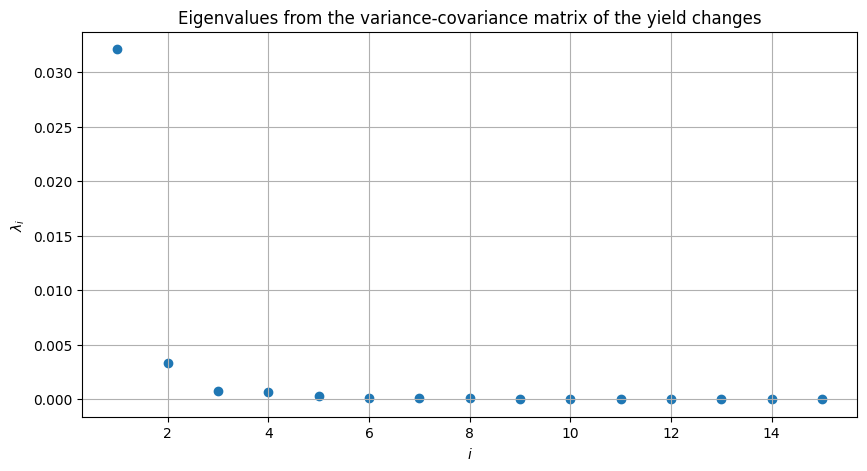

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(np.arange(1,len(vals_dY)+1), vals_dY )
plt.title('Eigenvalues from the variance-covariance matrix of the yield changes')
plt.xlabel(r'$i$')
plt.ylabel(r'$\lambda_i$')
plt.grid()
plt.show()

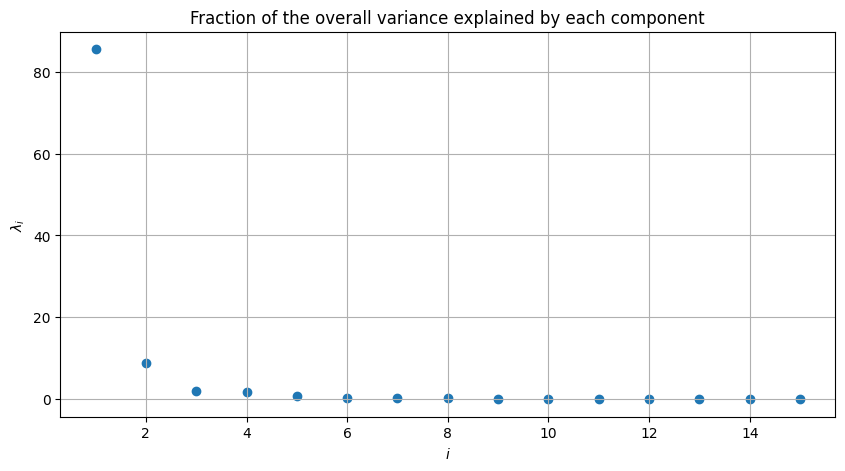

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(np.arange(1,len(vals_dY)+1), vals_dY/vals_dY.sum()*100 )
plt.title('Fraction of the overall variance explained by each component')
plt.xlabel(r'$i$')
plt.ylabel(r'$\lambda_i$')
plt.grid()
plt.show()

It is also instructive to examine the eigenvectors associated with the largest eigenvalues of $\boldsymbol{\Sigma}$.

Plotting the first three eigenvectors provides the familiar interpretation in terms of the **level**, **slope**, and **curvature** factors that characterize the majority of movements in the yield curve.

The first eigenvector, typically referred to as the **level** factor, loads with the same sign and similar magnitude across all maturities. This indicates that its associated eigenvalue captures broad parallel shifts of the yield curve, reflecting changes that raise or lower rates uniformly across maturities.


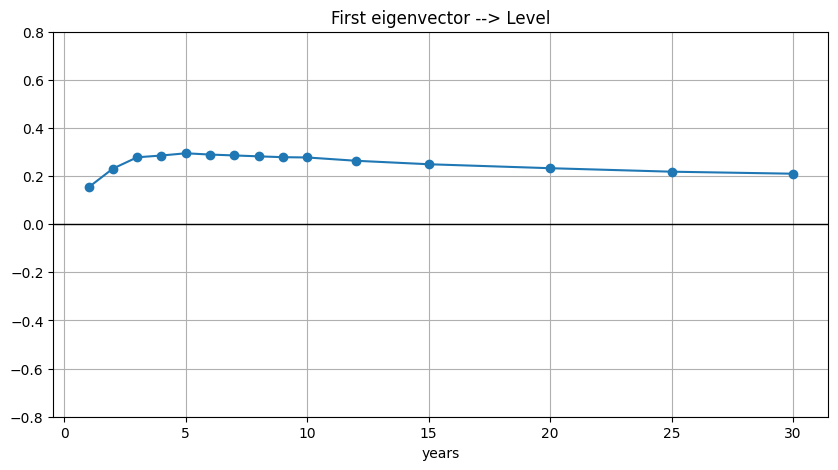

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(maturities, x1 , marker="o")
plt.xlabel('years')
plt.title('First eigenvector --> Level')
plt.ylim(-0.8, 0.8)
plt.axhline(0, color="black", linewidth=1)
plt.grid()
plt.show()

The second eigenvector corresponds to the **slope** factor.

It typically exhibits opposite signs at the short and long ends of the curve, capturing movements that steepen or flatten the term structure.
Its contribution therefore reflects shifts in the relative stance of short- versus long-term rates, often linked to monetary policy actions and market expectations about future economic conditions.


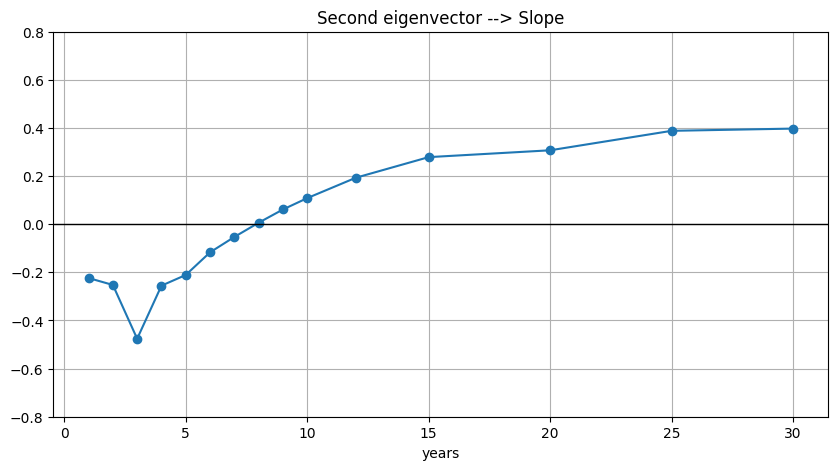

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(maturities, x2 , marker="o")
plt.xlabel('years')
plt.title('Second eigenvector --> Slope')
plt.ylim(-0.8, 0.8)
plt.axhline(0, color="black", linewidth=1)
plt.grid()
plt.show()

The third eigenvector represents the **curvature** factor.

It usually displays a pattern with opposite signs at intermediate maturities relative to the short and long ends, capturing changes in the hump of the yield curve. This factor highlights adjustments that leave the overall level and slope largely unchanged but modify the relative prominence of medium-term rates.

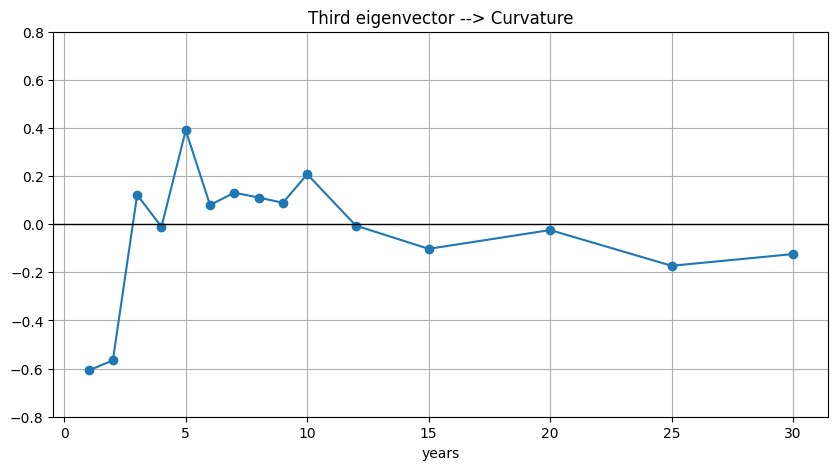

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(maturities, x3 , marker="o")
plt.xlabel('years')
plt.title('Third eigenvector --> Curvature')
plt.ylim(-0.8, 0.8)
plt.axhline(0, color="black", linewidth=1)
plt.grid()
plt.show()

We now turn to a simple application that highlights the explanatory power of the principal components.  

By projecting the observed yield changes onto the leading eigenvectors and reconstructing them from these projections, we can evaluate how much of the original cross-sectional variation is accounted for by the dominant factors.

Consider the yield changes on a given day: extract the corresponding row of $\Delta \mathbf{Y}$ and denote it by $\Delta \mathbf{y}$. The values of the principal components on that day, $\{ f_i \}_{i=1,\dots,m}$, are obtained as
$$
f_i = (\Delta \mathbf{y})\, \mathbf{x}_i.
$$

In what follows, we focus on the first three principal components, associated with the level, slope, and curvature factors described above.


In [ ]:
i = 0

dy = dY.iloc[i].values

f1 = dy @ x1
f2 = dy @ x2
f3 = dy @ x3

We now reconstruct the entire row of yield changes, recalling that
$$
\Delta \mathbf{y} = \sum_{i=1}^m f_i\, \mathbf{x}_i.
$$
To illustrate the effect of dimensionality reduction, we approximate $\Delta \mathbf{y}$ using only the first factor, then the first two, and finally the first three.

Comparing these successive reconstructions with the original row of yield changes allows us to assess how effectively the leading principal components capture the cross-sectional movement observed on that day.


In [ ]:
recon1 = f1 * x1
recon2 = f1 * x1 + f2 * x2
recon3 = f1 * x1 + f2 * x2 + f3 * x3

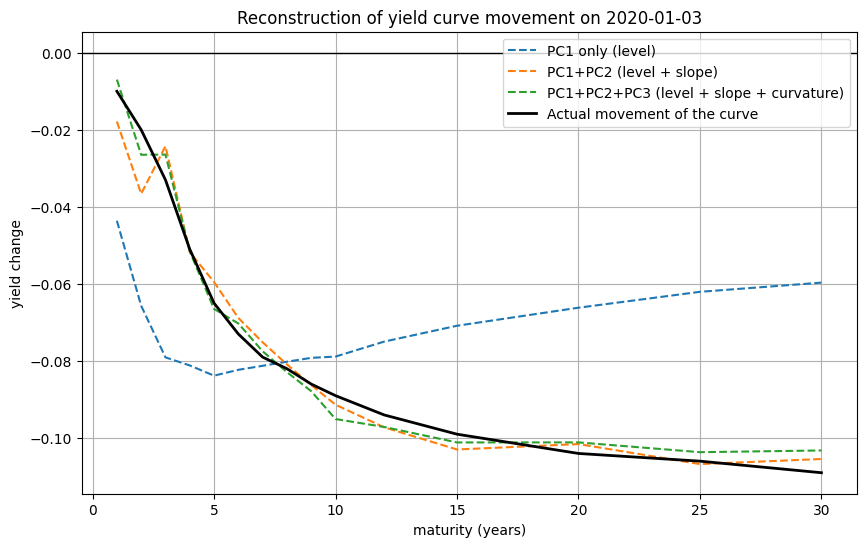

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(maturities, recon1, '--',  label="PC1 only (level)")
plt.plot(maturities, recon2, '--', label="PC1+PC2 (level + slope)")
plt.plot(maturities, recon3, '--', label="PC1+PC2+PC3 (level + slope + curvature)")
plt.plot(maturities, dy, color = 'k', label="Actual movement of the curve", linewidth=2)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("maturity (years)")
plt.ylabel("yield change")
plt.title(f"Reconstruction of yield curve movement on {dY.index[i].date()}")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def plot_reconstruction(i = 0):

  dy = dY.iloc[i].values
  f1 = dy @ x1
  f2 = dy @ x2
  f3 = dy @ x3
  recon1 = f1 * x1
  recon2 = f1 * x1 + f2 * x2
  recon3 = f1 * x1 + f2 * x2 + f3 * x3

  plt.figure(figsize=(10,6))

  plt.plot(maturities, recon1, '--',  label="PC1 only (level)")
  plt.plot(maturities, recon2, '--', label="PC1+PC2 (level + slope)")
  plt.plot(maturities, recon3, '--', label="PC1+PC2+PC3 (level + slope + curvature)")
  plt.plot(maturities, dy, color = 'k', label="Actual movement of the curve", linewidth=2)

  plt.axhline(0, color="black", linewidth=1)
  plt.xlabel("maturity (years)")
  plt.ylabel("yield change")
  plt.title(f"Reconstruction of yield curve movement on {dY.index[i].date()}")
  plt.grid(True)
  plt.legend()
  plt.show()

interact(plot_reconstruction, i=(0, len(df), 1));

interactive(children=(IntSlider(value=0, description='i', max=1041), Output()), _dom_classes=('widget-interact…

This analysis underscores the advantages of a principal components factor-based representation when modelling yield changes.  

By working with a small number of principal components, we reduce the dimensionality of the problem while retaining the vast majority of the relevant variation.  

A key benefit is that the loadings, captured here by the eigenvectors, are assumed to remain constant, allowing the dynamics to be driven entirely by the evolution of the factors themselves. This separation between stable cross-sectional structure and time-varying factor realizations leads to parsimonious, interpretable, and tractable models of yield-curve movements.